In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [55]:
import zipfile
with zipfile.ZipFile(r"/content/PRCP-1016-HeartDieseasePred.zip","r") as zip_ref:
  zip_ref.extractall()

In [56]:
df=pd.read_csv("/content/Data/values.csv")

In [57]:
df1=pd.read_csv("/content/Data/labels.csv")

In [58]:
data= df

In [59]:
data1=df1

In [60]:
df

,patient_id,slope_of_peak_exercise_st_segment,thal,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina
0,0z64un,1,normal,128,2,0,0,2,308,0.0,1,45,170,0
1,ryoo3j,2,normal,110,3,0,0,0,214,1.6,0,54,158,0
2,yt1s1x,1,normal,125,4,3,0,2,304,0.0,1,77,162,1
3,l2xjde,1,reversible_defect,152,4,0,0,0,223,0.0,1,40,181,0
4,oyt4ek,3,reversible_defect,178,1,0,0,2,270,4.2,1,59,145,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175,5qfar3,2,reversible_defect,125,4,2,1,0,254,0.2,1,67,163,0
176,2s2b1f,2,normal,180,4,0,0,1,327,3.4,0,55,117,1
177,nsd00i,2,reversible_defect,125,3,0,0,0,309,1.8,1,64,131,1
178,0xw93k,1,normal,124,3,2,1,0,255,0.0,1,48,175,0


In [61]:
df1

,patient_id,heart_disease_present
0,0z64un,0
1,ryoo3j,0
2,yt1s1x,1
3,l2xjde,1
4,oyt4ek,0
...,...,...
175,5qfar3,1
176,2s2b1f,1
177,nsd00i,1
178,0xw93k,0


In [62]:
#Data Understanding

In [63]:
#Merging because the main target is to predict Heart Disease

In [64]:
df2 = pd.merge(df, df1, on='patient_id', how='inner')
display(df2.head())

,patient_id,slope_of_peak_exercise_st_segment,thal,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,heart_disease_present
0,0z64un,1,normal,128,2,0,0,2,308,0.0,1,45,170,0,0
1,ryoo3j,2,normal,110,3,0,0,0,214,1.6,0,54,158,0,0
2,yt1s1x,1,normal,125,4,3,0,2,304,0.0,1,77,162,1,1
3,l2xjde,1,reversible_defect,152,4,0,0,0,223,0.0,1,40,181,0,1
4,oyt4ek,3,reversible_defect,178,1,0,0,2,270,4.2,1,59,145,0,0


In [65]:
df2.head()

,patient_id,slope_of_peak_exercise_st_segment,thal,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,heart_disease_present
0,0z64un,1,normal,128,2,0,0,2,308,0.0,1,45,170,0,0
1,ryoo3j,2,normal,110,3,0,0,0,214,1.6,0,54,158,0,0
2,yt1s1x,1,normal,125,4,3,0,2,304,0.0,1,77,162,1,1
3,l2xjde,1,reversible_defect,152,4,0,0,0,223,0.0,1,40,181,0,1
4,oyt4ek,3,reversible_defect,178,1,0,0,2,270,4.2,1,59,145,0,0


In [66]:
df2.tail()

,patient_id,slope_of_peak_exercise_st_segment,thal,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,heart_disease_present
175,5qfar3,2,reversible_defect,125,4,2,1,0,254,0.2,1,67,163,0,1
176,2s2b1f,2,normal,180,4,0,0,1,327,3.4,0,55,117,1,1
177,nsd00i,2,reversible_defect,125,3,0,0,0,309,1.8,1,64,131,1,1
178,0xw93k,1,normal,124,3,2,1,0,255,0.0,1,48,175,0,0
179,2nx10r,1,normal,160,3,1,0,0,201,0.0,0,54,163,0,0


In [67]:
merged_df=df2

In [68]:
#Data cleaning

In [69]:
df2.isnull().sum()

,0
patient_id,0
slope_of_peak_exercise_st_segment,0
thal,0
resting_blood_pressure,0
chest_pain_type,0
num_major_vessels,0
fasting_blood_sugar_gt_120_mg_per_dl,0
resting_ekg_results,0
serum_cholesterol_mg_per_dl,0
oldpeak_eq_st_depression,0


In [70]:
df2.duplicated().sum()


np.int64(0)

In [71]:
#Dropping patient_id as it unique and not relevant with the prediction

df2.drop("patient_id",axis=1,inplace=True)

In [72]:
#Exploaratory Data Analysis(EDA)

In [73]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 14 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   slope_of_peak_exercise_st_segment     180 non-null    int64  
 1   thal                                  180 non-null    object 
 2   resting_blood_pressure                180 non-null    int64  
 3   chest_pain_type                       180 non-null    int64  
 4   num_major_vessels                     180 non-null    int64  
 5   fasting_blood_sugar_gt_120_mg_per_dl  180 non-null    int64  
 6   resting_ekg_results                   180 non-null    int64  
 7   serum_cholesterol_mg_per_dl           180 non-null    int64  
 8   oldpeak_eq_st_depression              180 non-null    float64
 9   sex                                   180 non-null    int64  
 10  age                                   180 non-null    int64  
 11  max_heart_rate_achi

In [74]:
df2.describe()

,slope_of_peak_exercise_st_segment,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,heart_disease_present
count,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000
mean,1.550000,131.311111,3.155556,0.694444,0.161111,1.050000,249.211111,1.010000,0.688889,54.811111,149.483333,0.316667,0.444444
std,0.618838,17.010443,0.938454,0.969347,0.368659,0.998742,52.717969,1.121357,0.464239,9.334737,22.063513,0.466474,0.498290
min,1.000000,94.000000,1.000000,0.000000,0.000000,0.000000,126.000000,0.000000,0.000000,29.000000,96.000000,0.000000,0.000000
25%,1.000000,120.000000,3.000000,0.000000,0.000000,0.000000,213.750000,0.000000,0.000000,48.000000,132.000000,0.000000,0.000000
50%,1.000000,130.000000,3.000000,0.000000,0.000000,2.000000,245.500000,0.800000,1.000000,55.000000,152.000000,0.000000,0.000000
75%,2.000000,140.000000,4.000000,1.000000,0.000000,2.000000,281.250000,1.600000,1.000000,62.000000,166.250000,1.000000,1.000000
max,3.000000,180.000000,4.000000,3.000000,1.000000,2.000000,564.000000,6.200000,1.000000,77.000000,202.000000,1.000000,1.000000


In [75]:
df2.shape

(180, 14)

In [76]:
df2.dtypes

,0
slope_of_peak_exercise_st_segment,int64
thal,object
resting_blood_pressure,int64
chest_pain_type,int64
num_major_vessels,int64
fasting_blood_sugar_gt_120_mg_per_dl,int64
resting_ekg_results,int64
serum_cholesterol_mg_per_dl,int64
oldpeak_eq_st_depression,float64
sex,int64


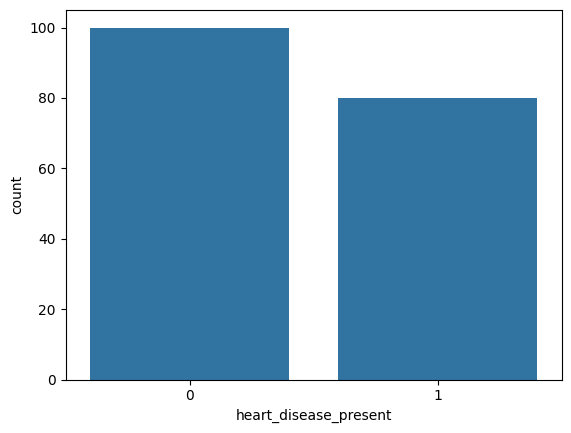

In [77]:
sns.countplot(x="heart_disease_present", data=df2)
plt.show()

<Axes: xlabel='age', ylabel='Count'>

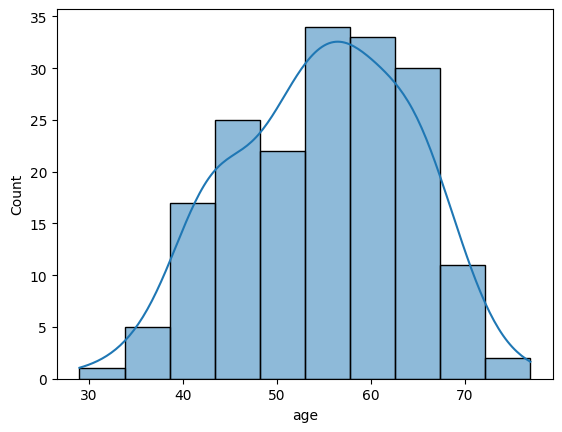

In [78]:
sns.histplot(df['age'],kde=True)

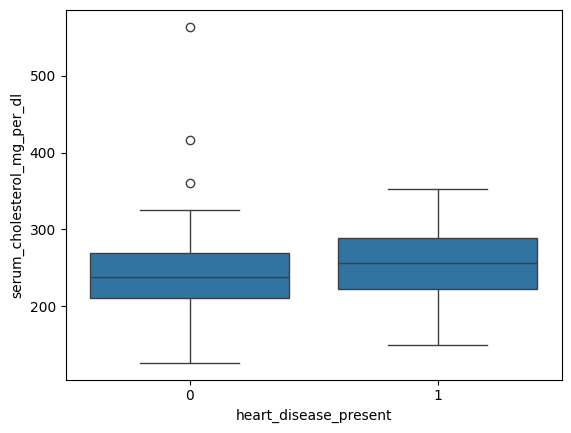

In [79]:
sns.boxplot(
    x='heart_disease_present',
    y='serum_cholesterol_mg_per_dl',
    data=df2
)
plt.show()

<Axes: xlabel='chest_pain_type', ylabel='count'>

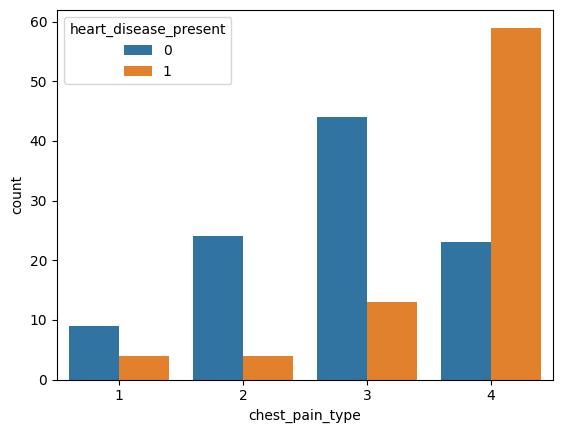

In [80]:
sns.countplot(
    x='chest_pain_type',
    hue='heart_disease_present',
    data=df2
)

In [81]:
'''
0 represents that patient does not have heart disease
1 represents that patient have heart disease
'''

'\n0 represents that patient does not have heart disease\n1 represents that patient have heart disease\n'

<Axes: xlabel='age', ylabel='Count'>

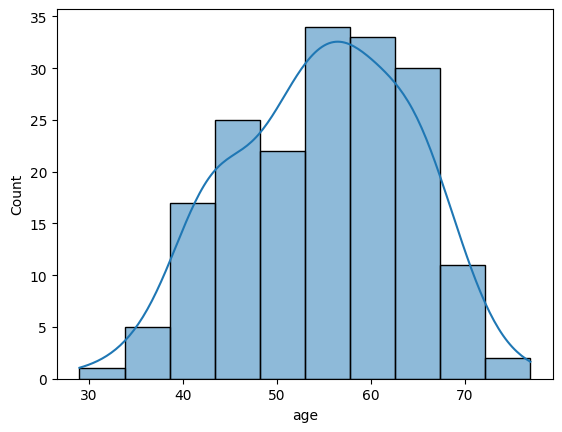

In [82]:
sns.histplot(df2['age'],kde=True)

In [83]:
df2['heart_disease_present'].value_counts() #Target

,count
heart_disease_present,
0,100
1,80


In [84]:
#Encoding

In [85]:
#As thal is categorical it is converted to numerical using Label_encoding

In [86]:
df2['thal'].value_counts()

,count
thal,
normal,98
reversible_defect,74
fixed_defect,8


In [87]:
import sklearn
from sklearn.preprocessing import LabelEncoder

LabelEncoder=LabelEncoder()
df2['thal']=LabelEncoder.fit_transform(df2['thal'])

In [88]:
#Train and Test

In [89]:
from sklearn.model_selection import train_test_split
x=df2.drop('heart_disease_present',axis=1)
y=df2['heart_disease_present']

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [90]:
#Model Building

In [91]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [92]:
Le=LogisticRegression(max_iter=1000)
Le.fit(x_train,y_train)
Le

LogisticRegression(max_iter=1000)

In [93]:
dt=DecisionTreeClassifier(random_state=42)
dt.fit(x_train,y_train)
dt

DecisionTreeClassifier(random_state=42)

In [94]:
rf=RandomForestClassifier(n_estimators=100 , random_state=42)
rf.fit(x_train,y_train)
rf

RandomForestClassifier(random_state=42)

In [95]:
#Model Evaluation | accuracy,classification_report & Re-call

In [96]:
from sklearn.metrics import accuracy_score

Le_predict=Le.predict(x_test)
accuracy_score(y_test,Le_predict)

0.8055555555555556

In [109]:
dF_predict=dt.predict(x_test)
accuracy_score(y_test,dF_predict)

0.7777777777777778

In [98]:
rf_predict=rf.predict(x_test)
accuracy_score(y_test,rf_predict)

0.8055555555555556

In [99]:
from sklearn.metrics import roc_auc_score

rf_prob=rf.predict(x_test)

roc_auc_score(y_test,rf_prob)

np.float64(0.81875)

In [100]:
from sklearn.metrics import roc_auc_score

dt_prob= dt.predict(x_test)

roc_auc_score(y_test,dt_prob)

np.float64(0.8)

In [101]:
Le_prob= Le.predict(x_test)

roc_auc_score(y_test,Le_prob)

np.float64(0.8125)

In [111]:
from sklearn.metrics import classification_report

print(classification_report(y_test, Le_predict))

              precision    recall  f1-score   support

           0       0.74      0.88      0.80        16
           1       0.88      0.75      0.81        20

    accuracy                           0.81        36
   macro avg       0.81      0.81      0.81        36
weighted avg       0.82      0.81      0.81        36



In [103]:
from sklearn.metrics import classification_report

print(classification_report(y_test, dt_pred))

              precision    recall  f1-score   support

           0       0.67      1.00      0.80        16
           1       1.00      0.60      0.75        20

    accuracy                           0.78        36
   macro avg       0.83      0.80      0.78        36
weighted avg       0.85      0.78      0.77        36



In [112]:
from sklearn.metrics import classification_report

print(classification_report(y_test, rf_predict))

              precision    recall  f1-score   support

           0       0.71      0.94      0.81        16
           1       0.93      0.70      0.80        20

    accuracy                           0.81        36
   macro avg       0.82      0.82      0.81        36
weighted avg       0.84      0.81      0.80        36



In [105]:
#Model comparison
'''
Model              	Accuracy Precision	Recall	F1-Score
Logistic Regression 	0.81    	0.82	   0.81	   0.81
Decision Tree	        0.78	    0.85	   0.78	   0.77
Random Forest	        0.81	    0.84	   0.81    0.80

Conclusion
Selected Model: Logistic Regression

Reason:

Highest F1-Score (0.81)
Highest balanced performance across all metrics
Same Accuracy as Random Forest (81%)
Better Recall for detecting heart disease patients (0.75 vs 0.70)
'''

'\nModel              \tAccuracy Precision\tRecall\tF1-Score\nLogistic Regression \t0.81    \t0.82\t   0.81\t   0.81\nDecision Tree\t        0.78\t    0.85\t   0.78\t   0.77\nRandom Forest\t        0.81\t    0.84\t   0.81    0.80\n\nConclusion\nSelected Model: Logistic Regression\n\nReason:\n\nHighest F1-Score (0.81)\nHighest balanced performance across all metrics\nSame Accuracy as Random Forest (81%)\nBetter Recall for detecting heart disease patients (0.75 vs 0.70)\n'

In [106]:
#Challanges
'''
as the data was divided in to 2 file, used merge technique
one categorical features given thal , converted it using Label_Encoding
'''

'\nas the data was divided in to 2 file, used merge technique\none categorical features given thal , converted it using Label_Encoding\n'